In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [5]:
df = pd.read_csv('C:/Python Programming/idr2usd-exchange-rate/data/processed/idr2usd-exchange-rate-processed.csv')

In [6]:

df.head()

,Unnamed: 0,Index,Bulan,USD
0,0,305,Mei 2026,17789.0
1,1,304,April 2026,17324.0
2,2,303,Maret 2026,16993.0
3,3,302,Februari 2026,16758.0
4,4,301,Januari 2026,16786.0


In [18]:
X = df['Index'].values.reshape(-1, 1)
X

array([[305],
       [304],
       [303],
       [302],
       [301],
       [300],
       [299],
       [298],
       [297],
       [296],
       [295],
       [294],
       [293],
       [292],
       [291],
       [290],
       [289],
       [288],
       [287],
       [286],
       [285],
       [284],
       [283],
       [282],
       [281],
       [280],
       [279],
       [278],
       [277],
       [276],
       [275],
       [274],
       [273],
       [272],
       [271],
       [270],
       [269],
       [268],
       [267],
       [266],
       [265],
       [264],
       [263],
       [262],
       [261],
       [260],
       [259],
       [258],
       [257],
       [256],
       [255],
       [254],
       [253],
       [252],
       [251],
       [250],
       [249],
       [248],
       [247],
       [246],
       [245],
       [244],
       [243],
       [242],
       [241],
       [240],
       [239],
       [238],
       [237],
       [236],
       [235],
      

In [19]:
y = df['USD'].values
y

array([17789., 17324., 16993., 16758., 16786., 16782., 16644., 16640.,
       16680., 16356., 16387., 16233., 16255., 16787., 16588., 16431.,
       16259., 16162., 15864., 15732., 15138., 15409., 16320., 16421.,
       16253., 16249., 15853., 15673., 15796., 15416., 15384., 15916.,
       15526., 15239., 15083., 15026., 14969., 14751., 15062., 15274.,
       14979., 15731., 15737., 15542., 15247., 14875., 14958., 14848.,
       14544., 14418., 14349., 14371., 14381., 14269., 14340., 14199.,
       14307., 14374., 14491., 14496., 14310., 14468., 14572., 14229.,
       14084., 14105., 14128., 14690., 14918., 14554., 14653., 14302.,
       14733., 15157., 16367., 14234., 13662., 13901., 14102., 14008.,
       14174., 14237., 14026., 14141., 14385., 14215., 14244., 14062.,
       14072., 14481., 14339., 15227., 14929., 14711., 14413., 14404.,
       13951., 13877., 13756., 13707., 13413., 13548., 13514., 13572.,
       13492., 13351., 13323., 13319., 13321., 13327., 13321., 13347.,
      

In [20]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((244, 1), (61, 1))

In [21]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 1137.7381
- Mean Absolute Error: 844.4921
- R2 Score: 0.8236
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1029.7264
- Mean Absolute Error: 751.9719
- R2 Score: 0.8557


Lasso
Model performance for Training set
- Root Mean Squared Error: 1137.7381
- Mean Absolute Error: 844.4940
- R2 Score: 0.8236
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1029.7265
- Mean Absolute Error: 751.9733
- R2 Score: 0.8557


Ridge
Model performance for Training set
- Root Mean Squared Error: 1137.7381
- Mean Absolute Error: 844.4923
- R2 Score: 0.8236
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1029.7264
- Mean Absolute Error: 751.9720
- R2 Score: 0.8557


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 290.4670
- Mean Absolute Error: 185.9590
- R2 Sco

In [23]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.990990
3,K-Neighbors Regressor,0.990721
5,Random Forest Regressor,0.989903
6,XGBRegressor,0.983849
4,Decision Tree,0.983618
8,AdaBoost Regressor,0.968582
0,Linear Regression,0.855672
2,Ridge,0.855672
1,Lasso,0.855672


In [29]:
lin_model = CatBoostRegressor(verbose=False)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 99.10


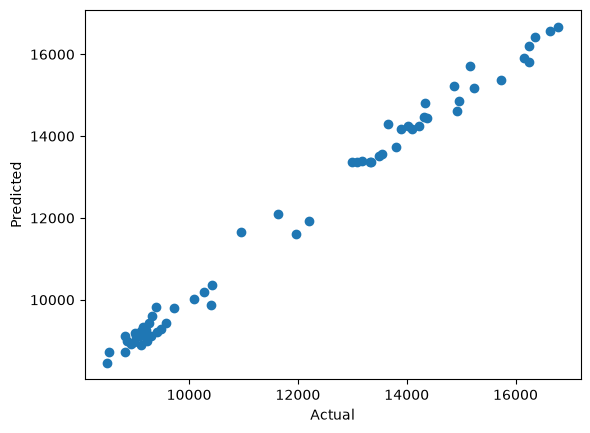

In [30]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

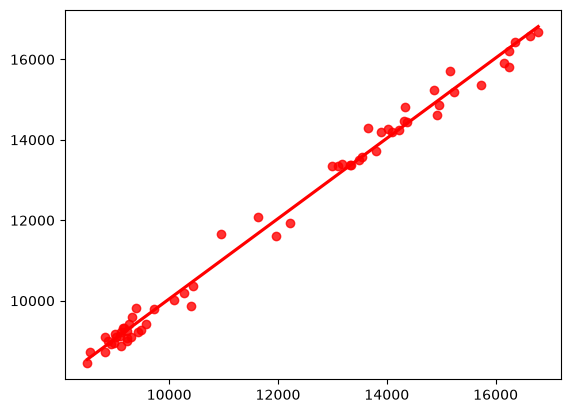

In [31]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [28]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
0,8537.0,11101.714571,-2564.714571
1,10278.0,11830.344333,-1552.344333
2,13347.0,13035.385862,311.614138
3,10090.0,9224.091722,865.908278
4,14310.0,14464.621165,-154.621165
...,...,...,...
56,9217.0,10036.794149,-819.794149
57,13492.0,13231.555414,260.444586
58,10400.0,7682.759533,2717.240467
59,9115.0,10709.375468,-1594.375468
